### Creating a Median Composite

#### Overview

We are now ready to perform a large computation to create a median composite image for a city using XArray and Dask, leveraging STAC and DuckDB for querying cloud-hosted data sources.

#### Overview of the Task

We will use the extracted city boundary from the previous step to query and load Sentinel-2 scenes for a chosen time-period and create a median composite. We will then clip and save the output as a Cloud-Optimized GeoTIFF (COG).

In [1]:
import dask
import matplotlib.pyplot as plt
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import pystac_client
import rioxarray as rxr
import xarray as xr
from odc.stac import configure_s3_access, load

Set up a local Dask cluster to distribute the computation across multiple workers on your computer.

In [2]:
from dask.distributed import Client

client = Client()   # set up local cluster on the machine
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 5
Total threads: 20,Total memory: 15.63 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:64746,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:64781,Total threads: 4
Dashboard: http://127.0.0.1:64782/status,Memory: 3.13 GiB
Nanny: tcp://127.0.0.1:64749,


#### Load Area of Interest

Read the file containing the city boundary.

In [3]:
output_dir = 'output'
fp_aoi = os.path.join(output_dir, 'aoi.geojson')

if not os.path.exists(fp_aoi):
    print(f'AOI file not found at {fp_aoi}. Using default AOI.')
    fp_aoi = ('https://storage.googleapis.com/spatialthoughts-public-data'
                '/python-remote-sensing/aoi.geojson')

Read the GeoJSON.

In [4]:
gdf_aoi = gpd.read_file(fp_aoi)

Extract the geometry.

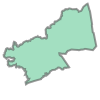

In [5]:
geometry = gdf_aoi.geometry.union_all()
geometry